# Validation Log and Notebook for AlexNet


The following notebook is going to be used to tweak the alexnet model for the different datasets, this is going to be done in order to make sure that we are picking the right architecture and hyperparameters for the efficiency tradeoff comparison.


##  Parameters Hyperparameters that we are going to change and validate:

Parameters: this are specific to each convulotional layer and focus on modifying how the convulotion operation is applied across the image.
We have to be really careful with this parameter as they dictate how much they are moving.
* Stride: This parameter determines how many units the filter moves at each step.
* Padding: This parameter determines how many zeros are going to be added arounf the input matrix border ir order to retain edge information and avoid shrinking.


Hyperparameters: 

## Vanilla Architecture: AlexNet as it was written on the breakthrough paper.


For this first validation iteration I am going to use the classic alexnet iteration with the vanilla hyperparameter that where established in the AlexNet Paper breakthrough we will see the overall perfomance of this model with the architecture that we have and see if we have to change any of the specific hyperparameters or parameters in the layers.

The first convulotional layer is the one that transforms the input data so thats where we are going to tweak the parameters.
The other hyperparameters in the other layers are going to be fixed.


### Validation with the MNIST dataset.

In [3]:
%pip install torchvision

Because I am using Colab and I remote server I have to clone the repo to access the local models.

In [ ]:
import os

REPO_NAME = "4803_project_advanced_neural_networks"
REPO_URL = "https://github.com/zarcop/4803_project_advanced_neural_networks"

# Clone once; then pull updates on later runs.
if not os.path.isdir(REPO_NAME):
    !git clone {REPO_URL}
else:
    !git -C {REPO_NAME} pull



Cloning into '4803_project_advanced_neural_networks'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 70 (delta 27), reused 65 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 22.32 MiB | 40.10 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/bin/bash: line 1: cd: model: No such file or directory


In [20]:
# Use %cd so working directory persists across notebook cells.
%cd /content/4803_project_advanced_neural_networks
!ls



4803_project_advanced_neural_networks  sample_data


## Stratified K-Fold Cross-Validation (AlexNET vs MNIST)

We are using Stratified K fold over all the different architecture options to make sure that we get the best performing architecture/configuration of alexNet in the MNIST dataset. This first validation process sets the baseline of how the validation process is going to work for all the overall th


100%|██████████| 9.91M/9.91M [00:00<00:00, 13.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 29.6MB/s]


CV Config: kernel: 3, stride : 1, padding: 1
Fold 1/3 | val_acc=97.25%
Fold 2/3 | val_acc=97.95%
Fold 3/3 | val_acc=97.22%
CV Config: kernel: 5, stride : 1, padding: 2
Fold 1/3 | val_acc=96.48%
Fold 2/3 | val_acc=96.00%
Fold 3/3 | val_acc=97.20%
CV Config: kernel: 5, stride : 2, padding: 2
Fold 1/3 | val_acc=97.48%
Fold 2/3 | val_acc=97.52%
Fold 3/3 | val_acc=95.23%
CV Config: kernel: 7, stride : 2, padding: 3
Fold 1/3 | val_acc=95.15%
Fold 2/3 | val_acc=96.75%
Fold 3/3 | val_acc=97.03%


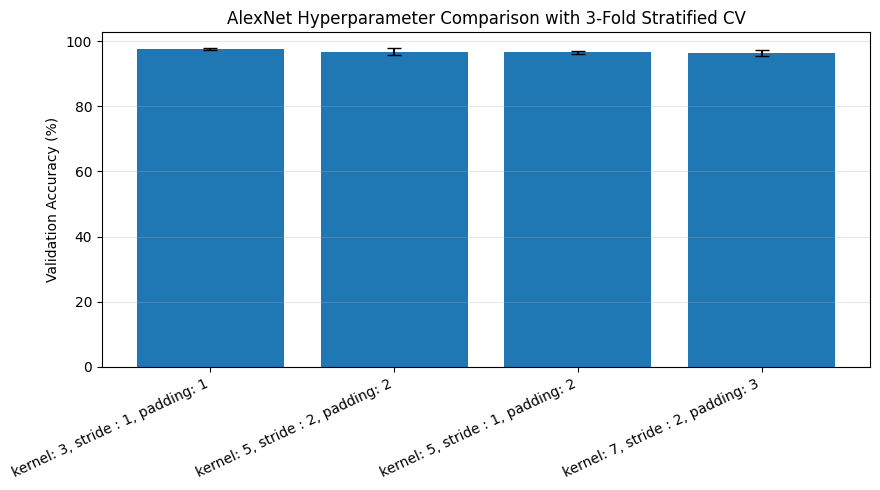


Best configuration by mean CV accuracy:
config         kernel: 3, stride : 1, padding: 1
mean_cv_acc                            97.471667
std_cv_acc                              0.341988
Name: 0, dtype: object


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset
import torch
import importlib.util
import sys
from pathlib import Path
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch import nn, optim

# Robust import from repo path (works even if cwd changes).
repo_root = Path("/content/4803_project_advanced_neural_networks")
model_dir = repo_root / "model"
alexnet_path = model_dir / "alexnet.py"

if not alexnet_path.exists():
    raise FileNotFoundError(f"Could not find {alexnet_path}. Make sure clone/pull cell ran successfully.")

if str(model_dir) not in sys.path:
    sys.path.insert(0, str(model_dir))

spec = importlib.util.spec_from_file_location("alexnet", alexnet_path)
alexnet = importlib.util.module_from_spec(spec)
spec.loader.exec_module(alexnet)
AlexNet4803 = alexnet.AlexNet4803
#connecting to our cuda kernel (I am using my own colab server)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ]
)
#downloading the data from MNIST
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)

#seed for reprodusability
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

#evaluation function (going to be reused for all the validations)
def evaluate(model: nn.Module, loader: DataLoader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            pred = logits.argmax(dim=1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    return 100.0 * correct / total

cv_dataset = train_data
cv_targets = np.array(train_data.targets)
#cross valiation hyperparameters
cv_hyperparameters = [
    {"k": 3, "s": 1, "p": 1, "name": "kernel: 3, stride : 1, padding: 1"},
    {"k": 5, "s": 1, "p": 2, "name": "kernel: 5, stride : 1, padding: 2"},
    {"k": 5, "s": 2, "p": 2, "name": "kernel: 5, stride : 2, padding: 2"},
    {"k": 7, "s": 2, "p": 3, "name": "kernel: 7, stride : 2, padding: 3"},
]
n_splits = 3
cv_epochs = 1
cv_batch_size = 128
lr = 1e-3

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
cv_records = []

#crossvalidation using skfold

for config in cv_hyperparameters:
    fold_accuracies = []
    print(f"CV Config: {config['name']}")

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(cv_targets)), cv_targets), start=1):
        fold_train = Subset(cv_dataset, train_idx.tolist())
        fold_val = Subset(cv_dataset, val_idx.tolist())

        fold_train_loader = DataLoader(fold_train, batch_size=cv_batch_size, shuffle=True, num_workers=0)
        fold_val_loader = DataLoader(fold_val, batch_size=cv_batch_size, shuffle=False, num_workers=0)

        model = AlexNet4803(1, 10, k1=config["k"], s1=config["s"], p1=config["p"]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss()

        for _ in range(cv_epochs):
            model.train()
            for images, labels in fold_train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = loss_fn(model(images), labels)
                loss.backward()
                optimizer.step()

        fold_acc = evaluate(model, fold_val_loader)
        fold_accuracies.append(fold_acc)
        print(f"Fold {fold_id}/{n_splits} | val_acc={fold_acc:.2f}%")

    mean_acc = float(np.mean(fold_accuracies))
    std_acc = float(np.std(fold_accuracies))
    cv_records.append(
        {
            "config": config["name"],
            "mean_cv_acc": mean_acc,
            "std_cv_acc": std_acc,
            "fold_accuracies": fold_accuracies,
        }
    )

cv_df = pd.DataFrame(cv_records).sort_values("mean_cv_acc", ascending=False).reset_index(drop=True)
cv_df

plt.figure(figsize=(9, 5))
plt.bar(
    cv_df["config"],
    cv_df["mean_cv_acc"],
    yerr=cv_df["std_cv_acc"],
    capsize=5,
)
plt.ylabel("Validation Accuracy (%)")
plt.title(f"AlexNet Hyperparameter Comparison with {n_splits}-Fold Stratified CV")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBest configuration by mean CV accuracy:")
print(cv_df.iloc[0][["config", "mean_cv_acc", "std_cv_acc"]])


## Stratified K-Validation for AlexNet on the CIFAR-10 dataset.

Similar procedure to the previous validation curve, the only difference is that I am going to test it in 

CV Config: kernel: 3, stride : 1, padding: 1
  Fold 1 Epoch 1/20 | train_loss=2.0096
  Fold 1 Epoch 20/20 | train_loss=0.7164
Fold 1/3 | val_acc=75.80% | max_class_dist_gap=0.0001
  Fold 2 Epoch 1/20 | train_loss=1.9069
  Fold 2 Epoch 20/20 | train_loss=0.6638
Fold 2/3 | val_acc=76.86% | max_class_dist_gap=0.0001
  Fold 3 Epoch 1/20 | train_loss=1.9735
  Fold 3 Epoch 20/20 | train_loss=0.7405
Fold 3/3 | val_acc=74.94% | max_class_dist_gap=0.0001
CV Config: kernel: 5, stride : 1, padding: 2
  Fold 1 Epoch 1/20 | train_loss=1.9755
  Fold 1 Epoch 20/20 | train_loss=0.7190
Fold 1/3 | val_acc=75.02% | max_class_dist_gap=0.0001
  Fold 2 Epoch 1/20 | train_loss=1.9702
  Fold 2 Epoch 20/20 | train_loss=0.6735
Fold 2/3 | val_acc=76.27% | max_class_dist_gap=0.0001
  Fold 3 Epoch 1/20 | train_loss=2.0302
  Fold 3 Epoch 20/20 | train_loss=0.6382
Fold 3/3 | val_acc=78.12% | max_class_dist_gap=0.0001
CV Config: kernel: 5, stride : 2, padding: 2
  Fold 1 Epoch 1/20 | train_loss=1.9928
  Fold 1 Epoch 

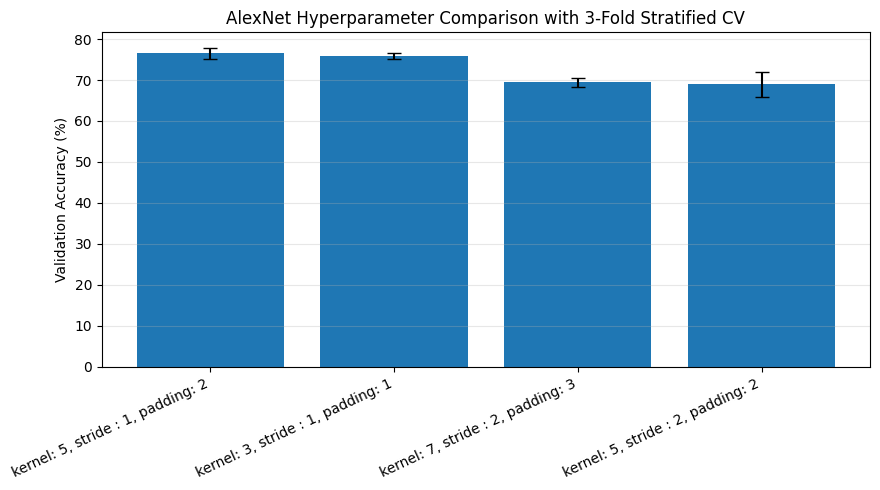


Best configuration by mean CV accuracy:
config         kernel: 5, stride : 1, padding: 2
mean_cv_acc                            76.468033
std_cv_acc                               1.27351
Name: 0, dtype: object


In [26]:

from torch.utils.data import Dataset

cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

#normalize the CIFAR dataset
train_transform = transforms.Compose(
    [transforms.RandomCrop(32, padding=4),transforms.RandomHorizontalFlip(), transforms.Resize((64, 64)), transforms.ToTensor(), transforms.Normalize(cifar10_mean, cifar10_std),]
)

val_transform = transforms.Compose([ transforms.Resize((64, 64)),transforms.ToTensor(),transforms.Normalize(cifar10_mean, cifar10_std),]
)

class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        image, label = self.base_dataset[int(self.indices[i])]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

# Download once without transform; apply transforms per fold.
base_train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=None)
_ = datasets.CIFAR10(root="./data", train=False, download=True, transform=None)

# Optional held-out test loader with eval transform 
test_data = datasets.CIFAR10(root="./data", train=False, download=False, transform=val_transform)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0)

seed = 69
torch.manual_seed(seed)
np.random.seed(seed)
cv_targets = np.array(base_train_data.targets, dtype=np.int64)
cv_hyperparameters = [
    {"k": 3, "s": 1, "p": 1, "name": "kernel: 3, stride : 1, padding: 1"},
    {"k": 5, "s": 1, "p": 2, "name": "kernel: 5, stride : 1, padding: 2"},
    {"k": 5, "s": 2, "p": 2, "name": "kernel: 5, stride : 2, padding: 2"},
    {"k": 7, "s": 2, "p": 3, "name": "kernel: 7, stride : 2, padding: 3"},
]

n_splits = 3
cv_epochs = 20
cv_batch_size = 128
lr = 1e-3

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
cv_records = []

for config in cv_hyperparameters:
    fold_accuracies = []
    print(f"CV Config: {config['name']}")

    for fold_id, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(cv_targets)), cv_targets), start=1):
        assert len(np.intersect1d(train_idx, val_idx)) == 0, "Train/val indices overlap"
        train_labels = cv_targets[train_idx]
        val_labels = cv_targets[val_idx]

        fold_train = TransformSubset(base_train_data, train_idx, train_transform)
        fold_val = TransformSubset(base_train_data, val_idx, val_transform)

        fold_train_loader = DataLoader(fold_train, batch_size=cv_batch_size, shuffle=True, num_workers=0)
        fold_val_loader = DataLoader(fold_val, batch_size=cv_batch_size, shuffle=False, num_workers=0)

        model = AlexNet4803(3, 10, k1=config["k"], s1=config["s"], p1=config["p"]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.CrossEntropyLoss()

        for epoch in range(1, cv_epochs + 1):
            model.train()
            running_loss = 0.0
            for images, labels in fold_train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = loss_fn(model(images), labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

            avg_loss = running_loss / max(len(fold_train_loader), 1)
            if epoch in {1, cv_epochs}:
                print(f"  Fold {fold_id} Epoch {epoch}/{cv_epochs} | train_loss={avg_loss:.4f}")

        fold_acc = evaluate(model, fold_val_loader)
        fold_accuracies.append(fold_acc)

        train_dist = np.bincount(train_labels, minlength=10) / len(train_labels)
        val_dist = np.bincount(val_labels, minlength=10) / len(val_labels)
        max_dist_gap = np.abs(train_dist - val_dist).max()
        print(f"Fold {fold_id}/{n_splits} | val_acc={fold_acc:.2f}% | max_class_dist_gap={max_dist_gap:.4f}")

    mean_acc = float(np.mean(fold_accuracies))
    std_acc = float(np.std(fold_accuracies))
    cv_records.append(
        {
            "config": config["name"],
            "mean_cv_acc": mean_acc,
            "std_cv_acc": std_acc,
            "fold_accuracies": fold_accuracies,
        }
    )

cv_df = pd.DataFrame(cv_records).sort_values("mean_cv_acc", ascending=False).reset_index(drop=True)
cv_df

plt.figure(figsize=(9, 5))
plt.bar(
    cv_df["config"],
    cv_df["mean_cv_acc"],
    yerr=cv_df["std_cv_acc"],
    capsize=5,
)
plt.ylabel("Validation Accuracy (%)")
plt.title(f"AlexNet Hyperparameter Comparison with {n_splits}-Fold Stratified CV")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBest configuration by mean CV accuracy:")
print(cv_df.iloc[0][["config", "mean_cv_acc", "std_cv_acc"]])


## Final Validation Pipeline: Tiny ImageNet-200

This section defines the final AlexNet validation procedure for Tiny ImageNet-200 with:

- robust dataset loading for Tiny ImageNet train/val structure,
- strong train-time preprocessing and augmentation,
- ImageNet-style normalization (best default for Tiny ImageNet),
- hyperparameter comparison over AlexNet first-layer options,
- plot of validation performance and final best configuration.


In [ ]:
import os
import zipfile
import urllib.request
from pathlib import Path
from collections import defaultdict
from PIL import Image

# 1) Data setup (Colab-friendly)
repo_root = Path("/content/4803_project_advanced_neural_networks")
data_root = repo_root / "model" / "data"
data_root.mkdir(parents=True, exist_ok=True)

# Tiny ImageNet official URL
# If download is blocked in your environment, manually upload/extract to `tiny_root`.
tiny_zip_url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
tiny_zip_path = data_root / "tiny-imagenet-200.zip"
tiny_root = data_root / "tiny-imagenet-200"

if not tiny_root.exists():
    if not tiny_zip_path.exists():
        print("Downloading Tiny ImageNet-200...")
        urllib.request.urlretrieve(tiny_zip_url, tiny_zip_path)
    print("Extracting Tiny ImageNet-200...")
    with zipfile.ZipFile(tiny_zip_path, "r") as zf:
        zf.extractall(data_root)

print(f"Tiny ImageNet root: {tiny_root}")

class TinyImageNetTrainDataset(Dataset):
    def __init__(self, root: Path, transform=None):
        self.root = Path(root)
        self.transform = transform
        wnids_path = self.root / "wnids.txt"
        self.classes = [line.strip() for line in wnids_path.read_text().splitlines() if line.strip()]
        self.class_to_idx = {wnid: idx for idx, wnid in enumerate(self.classes)}
        self.samples = []
        train_dir = self.root / "train"
        for wnid in self.classes:
            img_dir = train_dir / wnid / "images"
            if not img_dir.exists():
                continue
            label_idx = self.class_to_idx[wnid]
            for img_path in img_dir.glob("*.JPEG"):
                self.samples.append((img_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label


class TinyImageNetValDataset(Dataset):
    def __init__(self, root: Path, class_to_idx, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.class_to_idx = class_to_idx
        val_dir = self.root / "val"
        images_dir = val_dir / "images"
        ann_path = val_dir / "val_annotations.txt"
        file_to_wnid = {}
        for line in ann_path.read_text().splitlines():
            parts = line.strip().split("\t")
            if len(parts) >= 2:
                file_to_wnid[parts[0]] = parts[1]
        self.samples = []
        for file_name, wnid in file_to_wnid.items():
            if wnid not in self.class_to_idx:
                continue
            img_path = images_dir / file_name
            self.samples.append((img_path, self.class_to_idx[wnid]))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label


# 3) Preprocessing and augmentation for the 
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)
train_transform_tiny = transforms.Compose(
    [transforms.RandomCrop(64, padding=4, padding_mode="reflect"), transforms.RandomHorizontalFlip(p=0.5), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

val_transform_tiny = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

# 4) Build datasets/loaders

train_dataset_tiny = TinyImageNetTrainDataset(tiny_root, transform=train_transform_tiny)
val_dataset_tiny = TinyImageNetValDataset(tiny_root, train_dataset_tiny.class_to_idx, transform=val_transform_tiny)
num_classes_tiny = len(train_dataset_tiny.classes)
assert num_classes_tiny == 200, f"Expected 200 classes, got {num_classes_tiny}"
batch_size_tiny = 128
train_loader_tiny = DataLoader(train_dataset_tiny, batch_size=batch_size_tiny, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tiny = DataLoader(val_dataset_tiny, batch_size=batch_size_tiny, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset_tiny)}")
print(f"Val samples:   {len(val_dataset_tiny)}")
print(f"Classes:       {num_classes_tiny}")

# 5) Training / validation utilities

def evaluate_top1(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / max(total, 1)


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / max(len(loader), 1)

# 6) Final validation sweep over AlexNet hyperparams
seed = 67
torch.manual_seed(seed)
np.random.seed(seed)
tiny_hyperparameters = [
    {"k": 3, "s": 1, "p": 1, "name": "k3-s1-p1"},
    {"k": 5, "s": 1, "p": 2, "name": "k5-s1-p2"},
    {"k": 5, "s": 2, "p": 2, "name": "k5-s2-p2"},
    {"k": 7, "s": 2, "p": 3, "name": "k7-s2-p3"},
]
epochs_tiny = 20
lr_tiny = 3e-4
weight_decay_tiny = 1e-4
tiny_records = []
for config in tiny_hyperparameters:
    print(f"\n=== Tiny ImageNet Config: {config['name']} ===")
    model = AlexNet4803(
        in_channels=3,
        k_classes=num_classes_tiny,
        k1=config["k"],
        s1=config["s"],
        p1=config["p"],
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr_tiny, weight_decay=weight_decay_tiny)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_tiny)
    loss_fn = nn.CrossEntropyLoss()
    history_val = []
    history_loss = []
    for epoch in range(1, epochs_tiny + 1):
        train_loss = train_one_epoch(model, train_loader_tiny, optimizer, loss_fn, device)
        val_acc = evaluate_top1(model, val_loader_tiny, device)
        scheduler.step()
        history_loss.append(train_loss)
        history_val.append(val_acc)

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs_tiny:
            print(f"Epoch {epoch:02d}/{epochs_tiny} | train_loss={train_loss:.4f} | val_top1={val_acc:.2f}%")
    best_val_acc = max(history_val)
    best_epoch = int(np.argmax(history_val) + 1)
    tiny_records.append(
        {
            "config": config["name"],
            "best_val_top1": float(best_val_acc),
            "best_epoch": best_epoch,
            "final_val_top1": float(history_val[-1]),
            "history_val": history_val,
            "history_loss": history_loss,
        }
    )
# 7) Results table and final plots
tiny_df = pd.DataFrame(tiny_records).sort_values("best_val_top1", ascending=False).reset_index(drop=True)
tiny_df
plt.figure(figsize=(9, 5))
plt.bar(tiny_df["config"], tiny_df["best_val_top1"], color="steelblue")
plt.ylabel("Best Validation Top-1 Accuracy (%)")
plt.title("AlexNet Hyperparameter Validation on Tiny ImageNet-200")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
for rec in tiny_records:
    plt.plot(rec["history_val"], label=rec["config"])
plt.xlabel("Epoch")
plt.ylabel("Validation Top-1 Accuracy (%)")
plt.title("Validation Curves on Tiny ImageNet-200")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("\nBest Tiny ImageNet configuration:")
print(tiny_df.iloc[0][["config", "best_val_top1", "best_epoch", "final_val_top1"]])


Extracting Tiny ImageNet-200...
Tiny ImageNet root: /content/4803_project_advanced_neural_networks/model/data/tiny-imagenet-200
Train samples: 100000
Val samples:   10000
Classes:       200

=== Tiny ImageNet Config: k3-s1-p1 ===
Epoch 01/20 | train_loss=5.1107 | val_top1=4.30%
